In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

from train import get_config, main

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Loading

In [3]:
dataset = "set_game"
config_dataset = f"../configs/{dataset}.yaml"
config_model = "../configs/htrm_set_game.yaml"
config_train = "../configs/train_set_game.yaml"

config = get_config(config_train, config_model, config_dataset)

In [4]:
config['nray'] = 0

In [5]:
trainer, model, ds, dls = main(config, mode="test")

Global seed set to 123456
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Generated dataset set_game with 0 examples, 
max nodes: 12, max edges: 8
Splits: train, val, test           with sizes: 0, 0, 0
Using BCE with logits loss (assumes logits output)


/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(


In [6]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if im.dtype == torch.bool:
        im = im.float()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1, interpolation='nearest', aspect='equal')
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

In [11]:
for example in ds.dataset:
    node_feats, im = example
    break

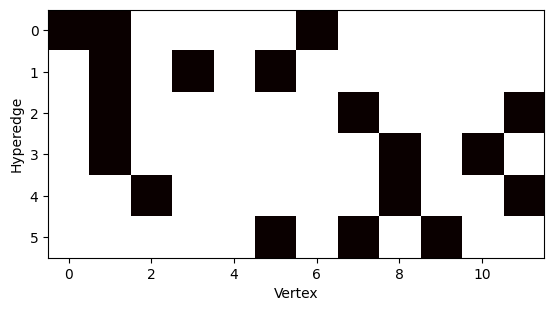

In [12]:
plot_incidence_matrix(im)

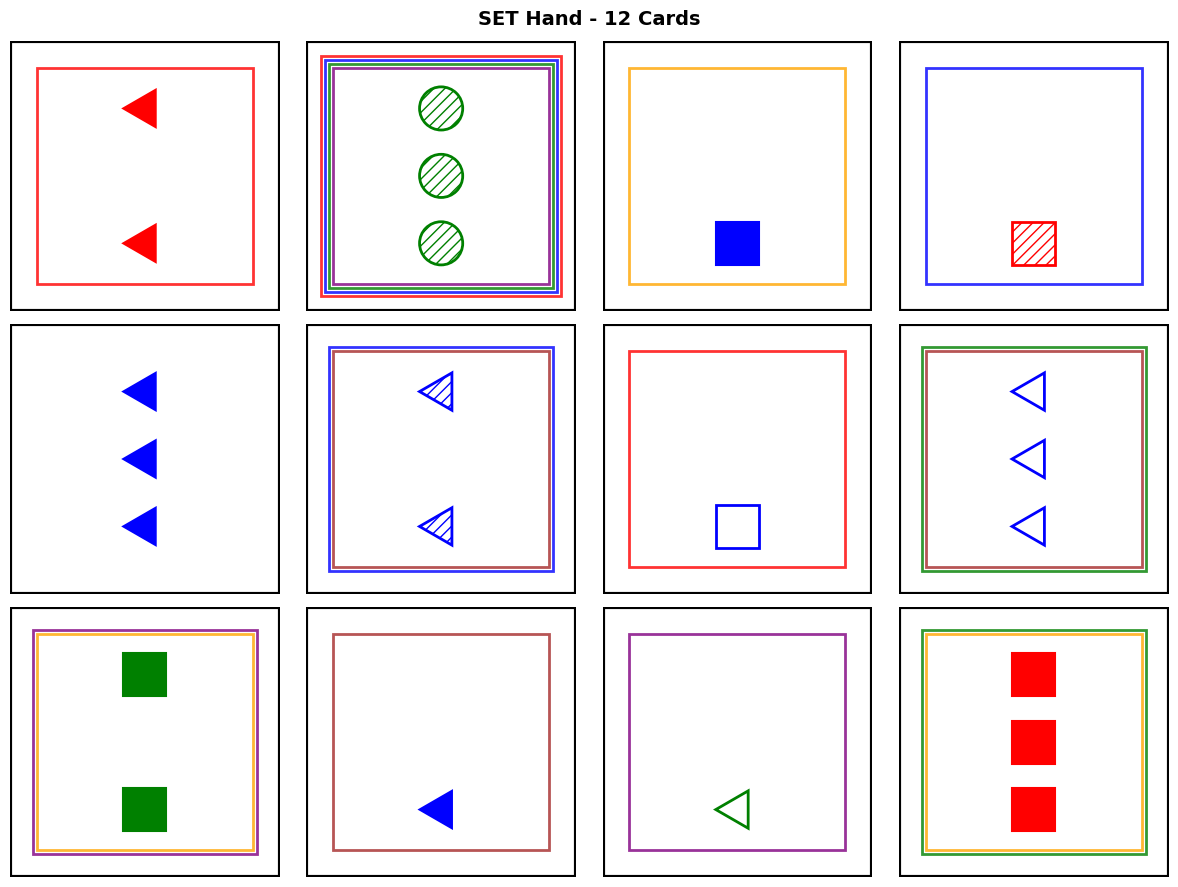

In [18]:
# Reload the updated visualization function
from utils.set_game_data import VisualizeSetHandV2

# Test with incidence matrix showing set memberships
VisualizeSetHandV2(node_feats.numpy(), im)
